## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.
**1.2522824482837894e-30**

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.
**Because the model has so many variables, it has extremely low bias but massive variance
. It perfectly memorizes the training data but completely fails to generalize to new data**

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.
**The cross-validated LASSO selected exactly 81 highly predictive genes and discarded the remaining 7048 by shrinking their coefficients completely to zero See code output for specific genes**

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?
**Overfitting occurs when a<105.24.
Underfitting occurs when a>105.24.
The optimal penalty is a=105.24.**

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.
**Linear regression performs perfectly on the training data because using thousands of variables allows it to strictly memorize the dataset, resulting in severe overfitting
. LASSO provides better predictions overall because it applies a penalty that shrinks the coefficients of unhelpful variables down to zero
. By automatically discarding these extra variables, LASSO reduces the model's complexity and variance, which prevents overfitting and helps the model actually generalize to new data**

7. Why do regularization methods lend themselves to scenarios like precision health?
**Regularization methods are perfect for precision health because medical datasets often have massive feature spaces but relatively few patients
. Regularization tames this complex data by automatically shrinking unhelpful variables to zero, which prevents severe overfitting
. This leaves you with a reliable, interpretable model that isolates only the most critical health predictors**

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?
**The biggest risk is confusing prediction with actual cause and effect
. LASSO biases its coefficients just to make better predictions, not to find the true underlying causes
. Because we don't have a real strategy to identify causal effects, medically intervening to change a specific variable won't necessarily improve the patient's health the way the model expects**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path, Lasso, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

In [6]:
df = pd.read_csv('/content/golub (1).csv')
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [10]:
cancer_dict = {'allB': 0, 'allT': 0, 'ALLB': 0, 'ALLT': 0, 'aml': 1, 'AML': 1}
df['target'] = df['cancer'].map(cancer_dict)

print(df['target'].value_counts())

target
0    47
1    25
Name: count, dtype: int64


Mean Squared Error: 1.2522824482837894e-30


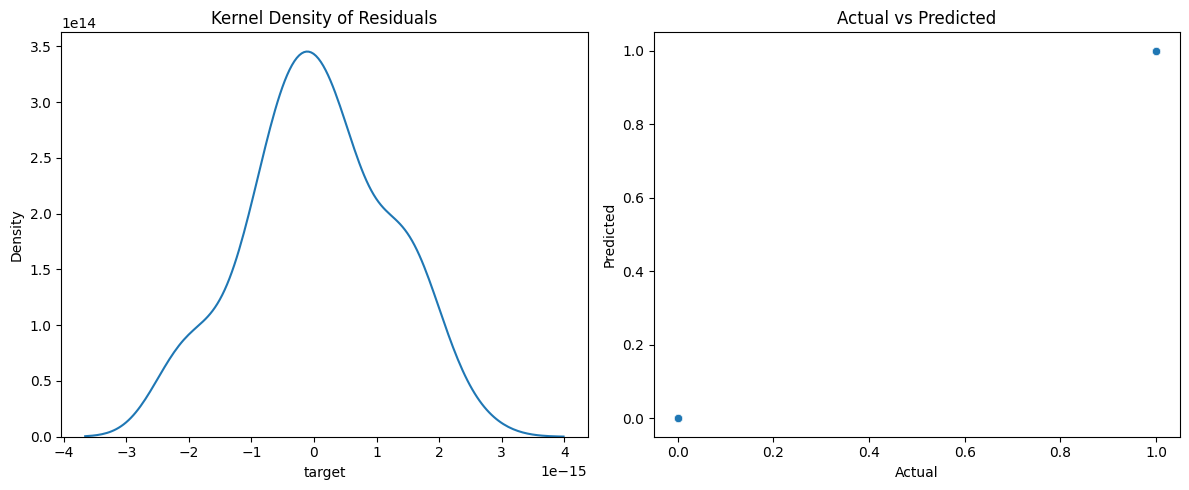

In [15]:
metadata = ['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'target']
X = df.drop(columns=metadata)
y = df['target']

model = LinearRegression()
model.fit(X, y)
y_hat = model.predict(X)

mse = np.mean((y - y_hat) ** 2)
print(f"Mean Squared Error: {mse}")

residuals = y - y_hat
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(residuals, ax=axes[0])
axes[0].set_title("Kernel Density of Residuals")

sns.scatterplot(x=y, y=y_hat, ax=axes[1])
axes[1].plot([1])
axes[1].set_title("Actual vs Predicted")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()

In [20]:
cv_mses = -cross_val_score(LinearRegression(), X, y, cv=10, scoring='neg_mean_squared_error')
print(f"Cross-Validated MSE: {cv_mses.mean()}")

Cross-Validated MSE: 0.06780005217137444


Number of selected genes: 81
Number of discarded genes: 7048
Selected gene names: ['AF000560_at', 'AF002020_at', 'AF006087_at', 'D26579_at', 'D29956_at', 'D42043_at', 'D50840_at', 'D86982_at', 'HG2161-HT2231_at', 'J04101_at', 'J04164_at', 'L12723_at', 'L13848_at', 'L20941_at', 'M12759_at', 'M17754_at', 'M19507_at', 'M20902_at', 'M22960_at', 'M23197_at', 'M27891_at', 'M28713_at', 'M31994_at', 'M34344_at', 'M63138_at', 'M84526_at', 'M95178_at', 'M96326_rna1_at', 'M98539_at', 'U10868_at', 'U14588_at', 'U30828_at', 'U34877_at', 'U36621_cds2_at', 'U46751_at', 'U50136_rna1_at', 'U51127_at', 'U60062_at', 'U82313_at', 'U82759_at', 'U88666_at', 'U89942_at', 'X04143_at', 'X14789_at', 'X16706_at', 'X53331_at', 'X56741_at', 'X63753_at', 'X66533_at', 'X66867_cds1_at', 'X69111_at', 'X81479_at', 'X83378_at', 'X95735_at', 'X96698_at', 'Y00636_at', 'Y07604_at', 'Y07755_at', 'Y10207_at', 'Y12670_at', 'M96843_at', 'X58072_at', 'AC002477_s_at', 'L15326_s_at', 'X57351_at', 'K02777_s_at', 'U37055_rna1_s_at'

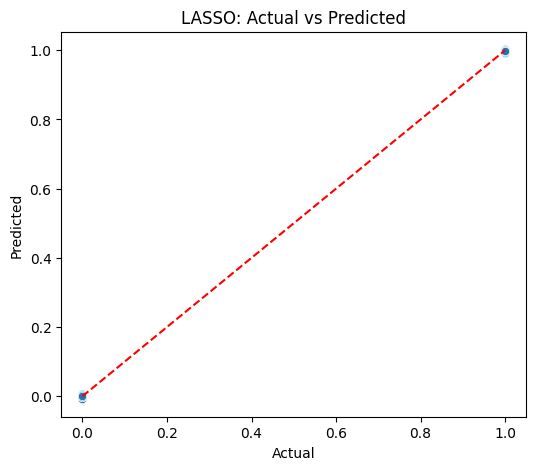

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso_model = LassoCV(cv=10, random_state=100, max_iter=10000)
lasso_model.fit(X_scaled, y)

coefs = lasso_model.coef_
selected_genes = X.columns[coefs != 0]
discarded_count = np.sum(coefs == 0)

print(f"Number of selected genes: {len(selected_genes)}")
print(f"Number of discarded genes: {discarded_count}")
print(f"Selected gene names: {list(selected_genes)}")

y_hat_lasso = lasso_model.predict(X_scaled)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=y, y=y_hat_lasso)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("LASSO: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

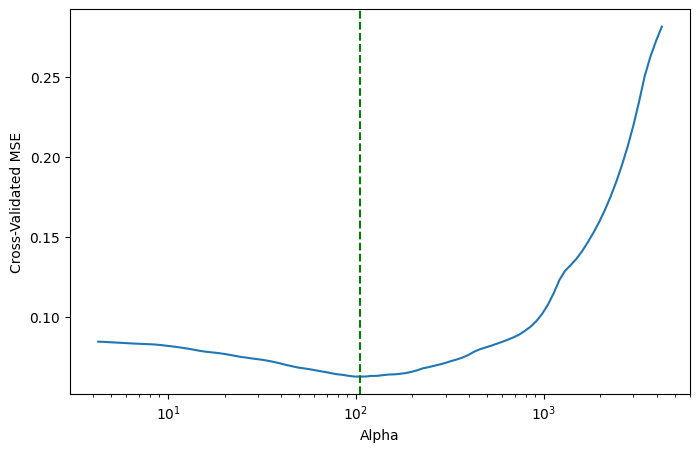

Optimal Alpha: 105.24436668425457


In [23]:
lasso_model = LassoCV(cv=5, random_state=100)
lasso_model.fit(X, y)

mean_mse = np.mean(lasso_model.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
sns.lineplot(x=lasso_model.alphas_, y=mean_mse)
plt.axvline(x=lasso_model.alpha_, color='green', linestyle='--')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Cross-Validated MSE')
plt.show()

print(f"Optimal Alpha: {lasso_model.alpha_}")